# Lab 1

Khanh Do

## Imports

In [6]:
import pandas as pd
import numpy as np

In [7]:
ic_homes = pd.read_csv("https://remiller1450.github.io/data/IowaCityHomeSales.csv")

# Import the scikit-learn library
import sklearn 

# Load all functions from the pre-processing module
from sklearn.preprocessing import *

# Load just the 'LinearRegression' function from the linear_model module
from sklearn.linear_model import LinearRegression

## Question 1

### Part A & Part B

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

## Question 2

### Part A

In [9]:
Q2_list = [[1.0,2.0,3.0], ['a','b','c'], [True, 1, False]]
print(Q2_list[0])

[1.0, 2.0, 3.0]


### Part B

In [10]:
print(type(Q2_list[2][1]))

<class 'int'>


## Question 3

### Part A

In [13]:
arr1 = np.array([1,2,3])
arr2 = np.array([-1,-2,-3])
arr_axis1 = np.stack((arr1, arr2), axis=1)
print(arr_axis1)

[[ 1 -1]
 [ 2 -2]
 [ 3 -3]]


**Explanation of changing axis:** It changes how the arrays stack, `0` stack row-wise and `1` stack column-wise.

### Part B

In [18]:
arr_axis1.ndim

2

**Explanation:** `ndim` tells us the number of dimensions of the array. `arr_axis1.ndim = 2` is correct because we created a matrix-like (have rows and columns) array.

In [ ]:
arr_axis1.size

6

**Explanation:** `size` tells us the total number of elements in the array. 

In [ ]:
arr_axis1.shape

(3, 2)

**Explanation:** `shape` tells us the size of the array along each dimension. Since we have 3 by 2 array, `arr_axis1.shape = (3 , 2)` is correct.

## Question 4

In [24]:
ic_homes = ic_homes.sort_values(by='assessed', ascending=False)
ic_homes.loc[ic_homes['bedrooms'] <= 3, ['sale.amount', 'sale.date']].head(5)

,sale.amount,sale.date
13,550000,2/25/2005
219,514750,1/20/2006
425,595150,2/23/2007
502,420000,6/13/2007
328,385000,7/3/2006


## Question 5

### Part A

<Axes: title={'center': 'Number of Bedrooms by Homes'}, xlabel='Number of Homes', ylabel='Number of Bedrooms'>

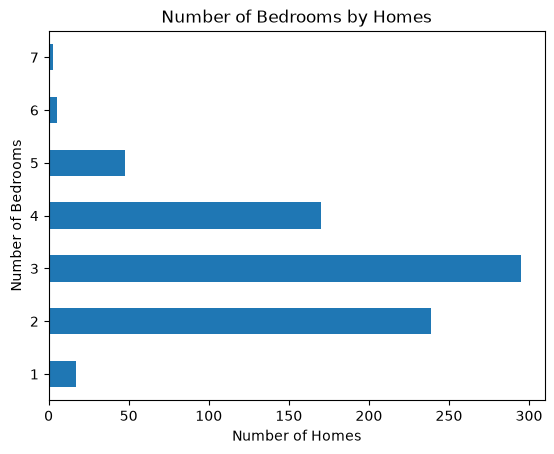

In [ ]:
ic_homes.groupby('bedrooms').size().plot(kind = 'barh', title = 'Number of Bedrooms by Homes', xlabel = 'Number of Homes', ylabel = 'Number of Bedrooms')

### Part B

         sale.amount       assessed
built                              
1873   270000.000000  250330.000000
1875   183500.000000  174920.000000
1880   219166.666667  245636.666667
1890   143466.666667  162830.000000
1893   287500.000000  278475.000000


<Axes: xlabel='built'>

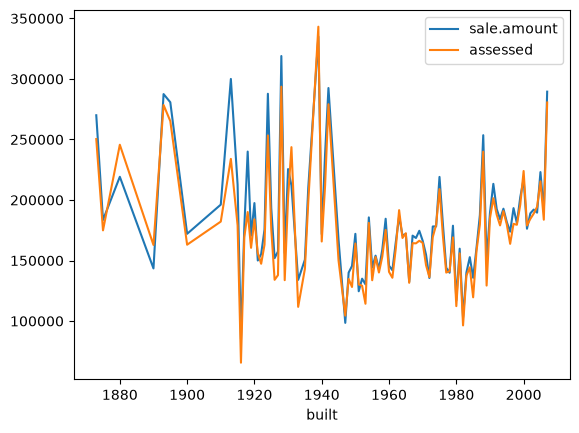

In [ ]:
data = ic_homes.groupby('built').agg({'sale.amount': 'mean', 'assessed': 'mean'})
print(data.head(5))
data.plot(kind='line')

## Question 6

### Part A

In [54]:
def find_speed_at_max_lane_dev(file_path: str):
    """
    Reads a CSV file, find the corresponding value of the variable VDS.Veh.Speed 
    when the variable SCC.Lane.Deviation.2 is at its maximum absolute value.

    Returns a single value.
    """
    df = pd.read_csv(file_path)
    
    curr_max_lane_dev = -float('inf')
    speed_at_max_lane_dev = None

    for _, row in df.iterrows():
        lane_dev = abs(row['SCC.Lane.Deviation.2'])
        speed = row['VDS.Veh.Speed']

        if lane_dev > curr_max_lane_dev:
            curr_max_lane_dev = lane_dev
            speed_at_max_lane_dev = speed

    return speed_at_max_lane_dev

### Part B

In [55]:
from pathlib import Path

dir_path = Path('./experiment')

file_paths = [str(path) for path in dir_path.iterdir() if path.is_file()]

for file_path in file_paths:
    print(f"Processing file: {file_path}")
    speed = find_speed_at_max_lane_dev(file_path)
    print(f"Max lane deviation speed for {file_path}: {speed}")

Processing file: experiment/run21_control.csv
Max lane deviation speed for experiment/run21_control.csv: 11.75429153
Processing file: experiment/run18_treatment.csv
Max lane deviation speed for experiment/run18_treatment.csv: 42.21751785
Processing file: experiment/run34_control.csv
Max lane deviation speed for experiment/run34_control.csv: 66.82077026
Processing file: experiment/run35_treatment.csv
Max lane deviation speed for experiment/run35_treatment.csv: 7.722750187
